# Laboratorio 3 — Visualización y Análisis Exploratorio de Datos
**Curso:** Minería de Datos (EIN132A25)

## Objetivos
- Aprender a construir gráficos con **matplotlib** y **seaborn**
- Detectar patrones, distribuciones y relaciones entre variables
- Analizar correlaciones

In [23]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
# Apagame todos los warning
import warnings
warnings.filterwarnings("ignore")

# url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
url = 'titanic.csv'
df = pd.read_csv(url)
sns.set_theme(style="whitegrid")
df.head(3)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S


## 1. Histograma — Distribución de Edades

891
29.8496231131986
30


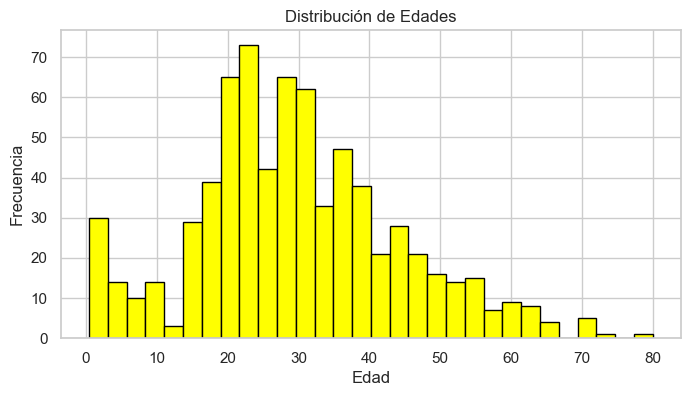

In [19]:
plt.figure(figsize=(8, 4))
# np.sqrt(len(df)) para determinar el número de bins
print(len(df))
print(np.sqrt(len(df)))
n_bins = int(np.round(np.sqrt(len(df))))
print(n_bins)
df["Age"].hist(bins=n_bins, color="yellow", edgecolor="black")
plt.title("Distribución de Edades")
plt.xlabel("Edad")
plt.ylabel("Frecuencia")
plt.show()

## 2. Histograma con KDE

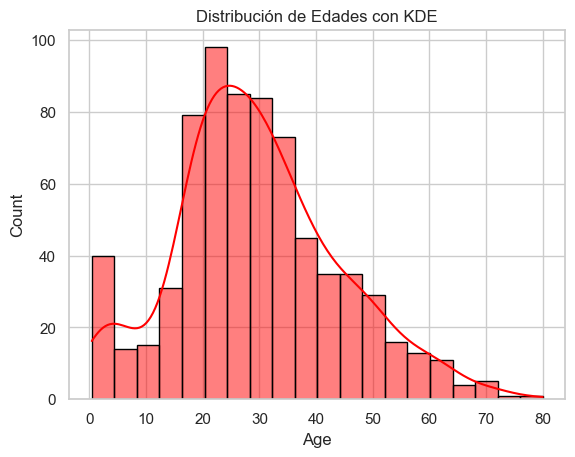

In [21]:
sns.histplot(df["Age"].dropna(), bins=20, kde=True, color="red", edgecolor='black')
plt.title("Distribución de Edades con KDE")
plt.show()

## 3. Boxplot — Edad según Supervivencia

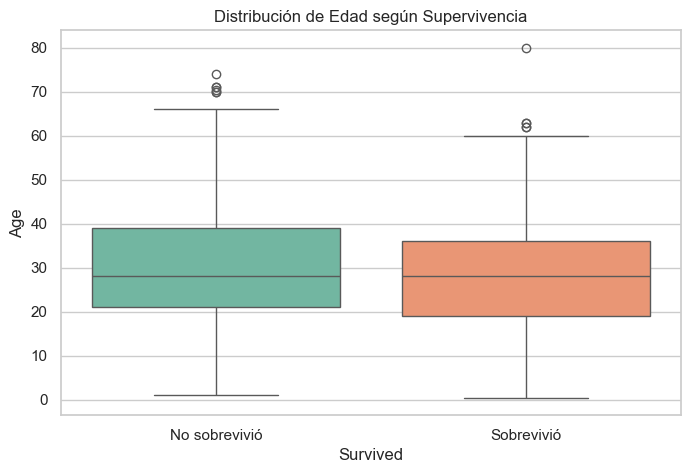

In [24]:
plt.figure(figsize=(8, 5))
sns.boxplot(x="Survived", y="Age", data=df, palette="Set2")
plt.title("Distribución de Edad según Supervivencia")
plt.xticks([0, 1], ["No sobrevivió", "Sobrevivió"])
plt.show()

## 4. Scatter Plot — Edad vs Tarifa

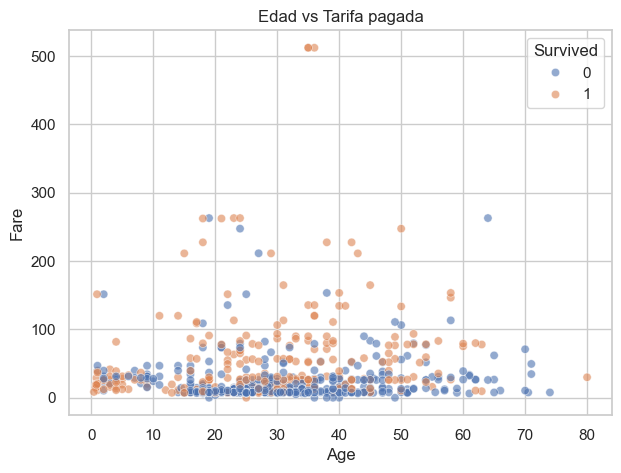

In [25]:
plt.figure(figsize=(7, 5))
sns.scatterplot(x="Age", y="Fare", hue="Survived", data=df, alpha=0.6)
plt.title("Edad vs Tarifa pagada")
plt.show()

## 5. Countplot — Supervivencia por clase

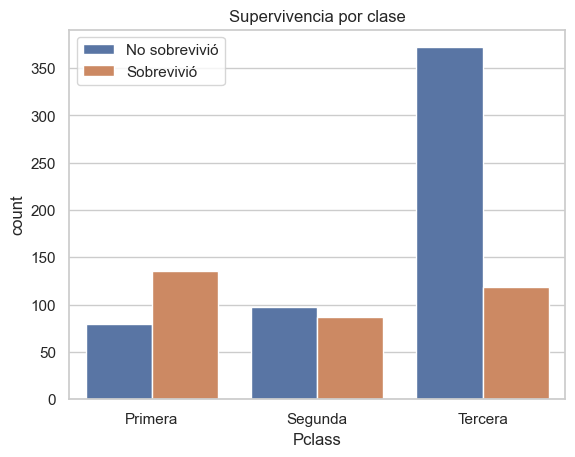

In [26]:
sns.countplot(x="Pclass", hue="Survived", data=df)
plt.title("Supervivencia por clase")
plt.xticks([0, 1, 2], ["Primera", "Segunda", "Tercera"])
plt.legend(["No sobrevivió", "Sobrevivió"])
plt.show()

## 6. Barplot — Tasa de supervivencia por sexo

In [ ]:
survival_by_sex = df.groupby("Sex")["Survived"].mean()
survival_by_sex.plot(kind="bar", color=["steelblue", "salmon"], edgecolor="black")
plt.title("Tasa de supervivencia por sexo")
plt.ylabel("Proporción")
plt.xticks(rotation=0)
plt.ylim(0, 1)
plt.show()

## 7. Heatmap de correlación

In [ ]:
corr = df.corr(numeric_only=True)
plt.figure(figsize=(9, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, square=True, linewidths=0.5)
plt.title("Mapa de calor de correlaciones")
plt.tight_layout()
plt.show()

## 8. Pairplot

In [ ]:
cols = ["Age", "Fare", "Pclass", "Survived"]
sns.pairplot(df[cols].dropna(), hue="Survived", palette="Set1")
plt.suptitle("Pairplot de variables principales", y=1.02)
plt.show()

## Ejercicios

### Ejercicio 1 — Histograma de Fare

In [ ]:
# TODO: crear histograma de Fare y describir la distribución
sns.histplot(df["Fare"], bins=30, kde=True, color="salmon")
plt.title("Distribución de Fare")
plt.show()

### Ejercicio 2 — Boxplot Fare por clase

In [ ]:
# TODO: boxplot comparando Fare entre las tres clases
sns.boxplot(x="Pclass", y="Fare", data=df, palette="Set2")
plt.title("Fare por clase")
plt.show()

### Ejercicio 3 — Tasa de supervivencia por clase

In [ ]:
# TODO: calcular y graficar tasa de supervivencia por Pclass
survival_by_class = df.groupby("Pclass")["Survived"].mean()
survival_by_class.plot(kind="barh", color="steelblue")
plt.title("Tasa de supervivencia por clase")
plt.xlabel("Proporción")
plt.show()

### Ejercicio 4 — Variable con mayor correlación con Survived

In [ ]:
# TODO: identificar variable con mayor correlación absoluta con Survived
corr_survived = df.corr(numeric_only=True)["Survived"].drop("Survived").abs().sort_values(ascending=False)
print(corr_survived)